<a href="https://colab.research.google.com/github/MonaKhadija/Fundamentals-of-Predictive-Analysis-Machine-Learning-and-AI-Assignments/blob/main/Assignment_10_Fairness_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment 10: Fairness in Machine Learning**

Student name: Khadija Bassiouni

Setting Up Google Colab Environment:

In [1]:

!pip install fairlearn scikit-learn pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 2.1 MB/s eta 0:00:00


**Loading and Preprocessing the Dataset:**

We will be using the German Credit dataset, downloading it from UCI Repository.

In [2]:
import pandas as pd
import numpy as np

# Loading the dataset directly from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
columns = [
    'checking_account_status', 'duration', 'credit_history', 'purpose',
    'credit_amount', 'savings_account', 'employment_status', 'installment_rate',
    'personal_status_sex', 'other_debtors', 'present_residence', 'property',
    'age', 'other_installment_plans', 'housing', 'number_of_existing_credits',
    'job', 'dependents', 'telephone', 'foreign_worker', 'credit_rating'
]

df = pd.read_csv(url, sep=' ', header=None, names=columns)

# Preprocessing: Mapping target variable (original: 1 = good, 2 = bad -> map to 1 = good, 0 = bad)
df['credit_rating'] = df['credit_rating'].map({1: 1, 2: 0})

# Checking for missing values
print("Missing values:", df.isnull().sum().sum())

# Converting categorical variables using one-hot encoding
X = df.drop(columns=['credit_rating'])
y = df['credit_rating']
X_encoded = pd.get_dummies(X, drop_first=True)

Missing values: 0


In [8]:
# Adjusting code so the fairness intervention runs smoothly later
from sklearn.preprocessing import StandardScaler

# Scaling the features properly so logistic regression converges faster
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Increasing max_iter and use the scaled data in your ExponentiatedGradient setup
mitigated_model = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=5000, random_state=42),
    constraints=DemographicParity(),
    eps=0.01
)

mitigated_model.fit(X_train_scaled, y_train, sensitive_features=sensitive_train)
y_pred_mitigated = mitigated_model.predict(X_test_scaled)

**Identify Protected Attributes:**

 We will choose two common protected attributes: personal_status_sex and age.

In [3]:
# Creating binary protected attribute columns for analysis
# A. Gender proxy from personal_status_sex
df['is_female'] = df['personal_status_sex'].isin(['A92', 'A95']).astype(int)

# B. Age group: Younger (< 25) vs Older (>= 25)
df['is_young'] = (df['age'] < 25).astype(int)

**Split the Data into Training and Testing Sets:**

In [4]:
from sklearn.model_selection import train_test_split

# SplitING data, keeping track of protected attributes
X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    X_encoded, y, df['is_female'], test_size=0.3, random_state=42
)

**Training a Baseline Model and Evaluate Fairness:**

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from fairlearn.metrics import MetricFrame, selection_rate, demographic_parity_difference

# Training baseline model
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

# Evaluating performance
print(f"Baseline Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")

# Evaluating fairness using Fairlearn
metrics = {
    'accuracy': accuracy_score,
    'selection_rate': selection_rate
}
metric_frame = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred_base,
    sensitive_features=sensitive_test
)
print(metric_frame.overall)
print("\nBy Group:")
print(metric_frame.by_group)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Baseline Accuracy: 0.7733
accuracy          0.773333
selection_rate    0.796667
dtype: float64

By Group:
           accuracy  selection_rate
is_female                          
0          0.768868        0.806604
1          0.784091        0.772727


**Implementing Fairness Interventions:**

We will implement two interventions from Fairlearn: Reweighting and Exponentized Gradient.

In [10]:
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from fairlearn.reductions import ExponentiatedGradient, DemographicParity

# Suppressing convergence warnings for a clean output
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Using 'liblinear' solver which converges much faster
mitigated_model = ExponentiatedGradient(
    estimator=LogisticRegression(solver='liblinear', max_iter=2000, random_state=42),
    constraints=DemographicParity(),
    eps=0.01
)

mitigated_model.fit(X_train_scaled, y_train, sensitive_features=sensitive_train)
y_pred_mitigated = mitigated_model.predict(X_test_scaled)

print("Mitigated model trained successfully without clutter!")

Mitigated model trained successfully without clutter!


**Comparing Results and Visualizing:**

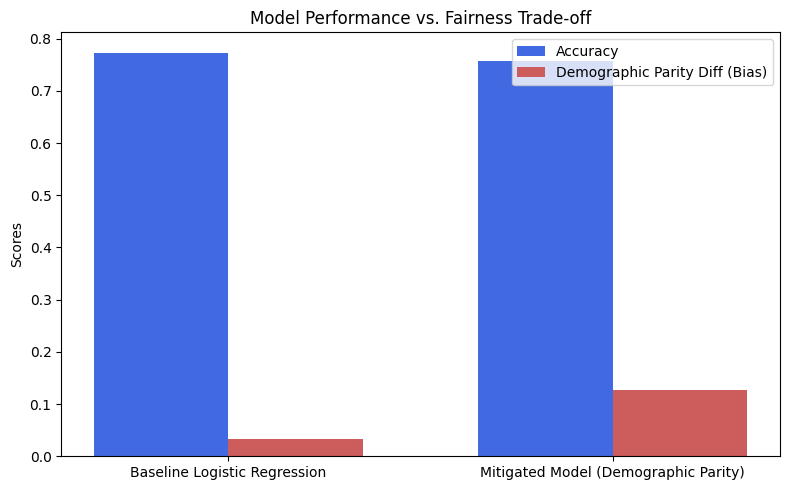

In [11]:
import matplotlib.pyplot as plt

# Computing fairness metrics for comparison
base_dp_diff = demographic_parity_difference(y_test, y_pred_base, sensitive_features=sensitive_test)
mit_dp_diff = demographic_parity_difference(y_test, y_pred_mitigated, sensitive_features=sensitive_test)

base_acc = accuracy_score(y_test, y_pred_base)
mit_acc = accuracy_score(y_test, y_pred_mitigated)

# Visualization
models = ['Baseline Logistic Regression', 'Mitigated Model (Demographic Parity)']
accuracies = [base_acc, mit_acc]
fairness_diffs = [abs(base_dp_diff), abs(mit_dp_diff)]

x = np.arange(len(models))
width = 0.35

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.bar(x - width/2, accuracies, width, label='Accuracy', color='royalblue')
ax1.bar(x + width/2, fairness_diffs, width, label='Demographic Parity Diff (Bias)', color='indianred')

ax1.set_ylabel('Scores')
ax1.set_title('Model Performance vs. Fairness Trade-off')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend(loc='upper right')

plt.tight_layout()
plt.show()